### Stock Trading Analysis

#### Important libraries

In [2]:
import yfinance as yf# it connects to yahoo finance to pull stock data
import mplfinance as mpf # for financial charts like candlestick
import numpy as np # The Math Engine
import pandas as pd # handles the data in a table format (DataFrame)
import statsmodels.api as sm # for the Statistics part like regression analysis
import scipy.stats as stats # for statistical analysis and probability
from matplotlib import pyplot as plt # Matplotlib is the base
import seaborn as sns # Seaborn makes the charts look modern and clean.
from plotly import express as px # creates Interactive charts.
import datetime as dt # to manage time ranges (e.g., "the last 5 years")
import os # save the results to folders on your computer.
from sqlalchemy import create_engine # to connect to MySQL
import urllib.parse  # Standard library to fix the password symbols
#---------------------------------------
pd.options.display.float_format = '{:,.2f}'.format # Round all numbers to 2 decimal places and add commas for thousands.
pd.options.display.max_rows = 1000 # This prevents Python from "hiding" rows because it usually shows the first 5 and last 5 rows
pd.options.display.max_columns = 1000
#---------------------------------------
sns.set() # applies the Seaborn styling to all charts

In [3]:
# Define a fucntion to add the titles, x, and y labels for charts
def style_labels_and_title(ax, x_label=None, xcolor='black', xbold=None, y_label=None, ycolor='black', ybold=None, title=None, tcolor='black', tsize=15, tbold=None):
    if x_label:
        ax.set_xlabel(x_label, fontsize=9, color=xcolor, fontweight=xbold)
    if y_label:
        ax.set_ylabel(y_label, fontsize=9, color=ycolor, fontweight=ybold)
    if title:
        ax.set_title(title, fontsize=tsize, color=tcolor, pad=20, fontweight=tbold)

**Connecting the data to MySQL**

In [4]:
# MySQL Connection Details
USER = 'root'
RAW_PASSWORD = 'youssef_md_3011@' 
# Encode password to handle special characters like '@'
SAFE_PASSWORD = urllib.parse.quote_plus(RAW_PASSWORD)
HOST = 'localhost'
PORT = '3306'
DATABASE = 'stock_data'

# Create the SQLAlchemy engine for MySQL
connection_string = f'mysql+pymysql://{USER}:{SAFE_PASSWORD}@{HOST}:{PORT}/{DATABASE}'
engine = create_engine(connection_string)

#### Downloading Data from Yahoo!

**Using a loop to fetch data, as yfinance.download handles one stock per call**

We will use the **Delta Strategy** (also known as an Incremental Load) is the process of updating your dataset by only fetching the "delta"—the new or changed data—since your last successful update.

Instead of downloading everything from 2020 every time you run your script, you look at your existing file, find the last date you recorded, and ask yfinance to give you only the data from that day forward.


-----------

**Note to the Reader**: The analysis, charts, and financial insights presented below are based on a dataset captured up to February 20, 2026. I have intentionally commented out (or hashtagged) the ETL pipeline blocks below to preserve the integrity of my findings.

If you execute these code blocks, the script will automatically fetch the most recent market data up to today's date. While the charts and code are fully dynamic and will update successfully, please be aware that the specific numbers, percentages, and outliers mentioned in my commentary may shift as new market data is integrated.

**Recommendation**: Review the existing analysis first to understand the established trends before re-running the ETL pipeline to update the database."

In [5]:
# Create a dictionary to map Yahoo Tickers (keys) to our specific CSV filenames (values)
ticker_map = {'AAPL': 'AAPL', 'TSLA': 'TSLA', 'MSFT': 'MSFT', 'GC=F': 'GOLD', 'SPY': 'SPY', 'AMZN': 'AMZN'}

# Get current system time and turn it into a clean string format like '2026-02-20'
today = dt.datetime.now().strftime('%Y-%m-%d') 

# Start a loop that pulls both the 'key' (ticker) and 'value' (filename) for each pair
for ticker, filename in ticker_map.items(): 
    
    # Create the full filename string by adding '.csv' to the end of our name (e.g., 'GOLD.csv')
    file_path = f"{filename}.csv"
    
    # Ask the Operating System: "Does a file with this name already sit in my folder?"
    if os.path.exists(file_path): 
        
        # Load the existing CSV data into a Pandas table (DataFrame)
        existing_df = pd.read_csv(file_path)
        
        # Convert the 'Date' column from plain text to specialized 'DateTime' objects for math
        existing_df['Date'] = pd.to_datetime(existing_df['Date']) 
        
        # Find the most recent (maximum) date currently stored in our file
        last_date = existing_df['Date'].max()
        
        # Add 1 day to the last date to find where the new download should start, then format it as text
        start_fetch = (last_date + dt.timedelta(days=1)).strftime('%Y-%m-%d')
        
        # Logic Check: If our next start date is today or later, we don't need to do anything
        if start_fetch >= today: 
            # Tell the user the data is already fresh
            print(f"✅ {filename.upper()} is already up to date.")
            # Skip all code below this line and jump immediately to the next stock in the loop
            continue   

        # If we reached this line, it means we NEED data. Print a message to show progress.
        print(f"🚀 Fetching {ticker} delta for {filename}.csv starting from {start_fetch}")
        
        # Ask the yfinance API to give us data from our 'start_fetch' date up until 'today'
        new_data = yf.download(ticker, start=start_fetch, end=today, auto_adjust=False)
        
        # Safety Check: Only proceed if the API actually found and returned rows of data
        if new_data is not None and not new_data.empty:
            try:

                # Fix the column names by removing the 'MultiIndex' layer (the double-header row)
                new_data.columns = new_data.columns.get_level_values(0)
                
                # Move the Date from being the index (side label) into a normal data column
                new_data = new_data.reset_index()
                
                # Add a new column to identify which stock this data belongs to
                new_data['Ticker'] = ticker
                
                # Glue the old data and new data together, then delete any rows where the Date is identical
                updated_df = pd.concat([existing_df, new_data]).drop_duplicates(subset=['Date'])
                
                # Save the final, updated table back to the CSV file, overwriting the old version
                updated_df.to_csv(file_path, index=False)

            except Exception as e:
                print(f"⚠️ Error processing {ticker}: {e}")
                
    # This block runs ONLY if the file_path was NOT found (first time running the code)
    else:
        # Inform the user that we are building a new database from scratch
        print(f"📥 Initial download for {ticker} -> {filename}.csv")
        
        # Download the entire history from 2020 until today
        df = yf.download(ticker, start="2020-01-01", auto_adjust=False)
        
        # Repeat the cleaning steps: Fix columns, reset index, and add the ticker label
        df.columns = df.columns.get_level_values(0)
        df = df.reset_index()
        df['Ticker'] = ticker
        
        # Create the new CSV file and save all the data into it
        df.to_csv(file_path, index=False)

✅ AAPL is already up to date.
✅ TSLA is already up to date.
✅ MSFT is already up to date.
✅ GOLD is already up to date.
🚀 Fetching SPY delta for SPY.csv starting from 2026-02-28


[*********************100%***********************]  1 of 1 completed

✅ AMZN is already up to date.


In [6]:
pd.read_csv('MSFT.csv').tail(3) 

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
1549,2026-03-04,405.20,405.20,411.03,400.31,401.27,35808000,MSFT
1550,2026-03-05,410.68,410.68,411.61,404.40,404.42,39001300,MSFT
1551,2026-03-06,408.96,408.96,413.05,408.51,409.30,30792826,MSFT


#### **Explaining the columns we have in our data**

**Open**: It’s the very first price someone paid for a share when the market opened at 9:30 AM.

**High**: This is the most expensive price anyone was willing to pay that entire day. It represents the moment of maximum optimism.

**Low**: The cheapest price the stock touched that day. It shows the moment of maximum fear or selling pressure.

**Close**: This is the price of the very last trade made at 4:00 PM when the market closed. This is the value most people refer to when they ask, "What is the stock price?"

**Adj Close (Adjusted Close)**: This is the True Value. If a company pays a dividend (gives cash back to shareholders) or does a stock split, the raw "Close" price doesn't show the full picture. The Adj Close calculates those "extra gains" back into the price.

**Volume**: Think of this as the Crowd Size. It’s the total number of shares that changed hands that day.


###### **Rule of Thumb: Use Close to see what happened on that day; use Adj Close to see how much money you actually made over time, and we are gonna be using only the Adj Close column**

In [7]:
# Define the function with a default list of columns to extract for the pivoted table
def create_master_files(cols=['Date', 'Adj Close']):
    """
    Part A: Stacks all columns for all stocks into a 'Long' table (good for deep analysis).
    Part B: Pivots 'Adj Close' so each stock has its own column (good for charting).
    """
    
    # --- PART A: RAW DATA STACKING (LONG FORMAT) ---
    
    # Create an empty list to hold every single stock's full data table
    all_data_list = []
    
    # Loop through the nicknames/filenames defined in your ticker_map
    for filename in ticker_map.values():
        file_path = f"{filename}.csv"
        
        # If the file exists on the computer, read it and add it to our list
        if os.path.exists(file_path):
            all_data_list.append(pd.read_csv(file_path))
    
    # If we successfully collected at least one file
    if all_data_list:
        # Stack all tables vertically (one on top of the other) into one giant table
        raw_master_df = pd.concat(all_data_list, ignore_index=True)
        
        # Save this giant "Raw" table as a CSV file
        raw_master_df.to_csv('all_stocks_raw.csv', index=False)
        
        # Upload this giant table to MySQL into a table named 'raw_stock_data'
        # 'replace' means it overwrites the old table with the new, full version
        raw_master_df.to_sql(name='all_stocks_raw', con=engine, if_exists='replace', index=False)
        print("📦 'all_stocks_raw.csv' and SQL table 'all_stocks_raw' created.")

    # --- PART B: PRICE PIVOTING (WIDE FORMAT) ---
    
    # Create a variable to hold the side-by-side table, starting as empty
    main_df = None
    
    # Loop through the filenames again to build the price-only table
    for filename in ticker_map.values():
        file_path = f'{filename}.csv'
        
        if os.path.exists(file_path):
            # Load only 'Date' and 'Adj Close', making 'Date' the index (the far-left ID column)
            df_temp = pd.read_csv(file_path, index_col='Date', parse_dates=True, usecols=cols)
            
            # Rename the 'Adj Close' column to the stock name (e.g., change 'Adj Close' to 'GOLD')
            df_temp = df_temp.rename(columns={'Adj Close': filename})
            
            # If this is the first stock, it becomes the foundation of our master table
            if main_df is None:
                main_df = df_temp
            else:
                # Glue the next stock's prices to the right side of the foundation using the dates to align them
                # 'outer' join ensures we keep dates even if some stocks are missing data that day
                main_df = main_df.join(df_temp, how='outer')

    # If the side-by-side table was successfully created
    if main_df is not None:
        # Remove any rows where all stocks are empty (like weekends) and sort dates oldest to newest
        df_final = main_df.dropna(how='all').sort_index()
        
        # Explicitly label the index column as 'Date'
        df_final.index.names = ['Date']
        
        # Change all column headers to lowercase (e.g., 'GOLD' becomes 'gold') for easier coding
        df_final.columns = [col.lower() for col in df_final.columns]
        
        # Save this cleaned price table as 'portfolio_prices.csv'
        df_final.to_csv('portfolio_prices.csv')
        
        # Upload this cleaned table to MySQL into a table named 'portfolio_prices'
        # index=True ensures the 'Date' column is included in the SQL table
        df_final.to_sql(name='portfolio_prices', con=engine, if_exists='replace', index=True)
        
        print("🏠 Master file 'portfolio_prices.csv' and SQL table 'portfolio_prices' updated.")
        
        # Return the final table so we can use it for previews or charts immediately
        return df_final

In [8]:
# 1. Run the function and store the result in a variable called 'df_final'
df_final =  create_master_files()
# 2. Check the results
if df_final is not None:
    print("\n✅ Success! Here are your latest stock prices:")
    display(df_final.tail()) # 'display' works better than 'print' in Jupyter
else:
    print("❌ Something went wrong. No data was returned.")

📦 'all_stocks_raw.csv' and SQL table 'all_stocks_raw' created.
🏠 Master file 'portfolio_prices.csv' and SQL table 'portfolio_prices' updated.

✅ Success! Here are your latest stock prices:


,aapl,tsla,msft,gold,spy,amzn
Date,,,,,,
2026-03-02,264.72,403.32,398.55,"5,294.40",686.38,208.39
2026-03-03,263.75,392.43,403.93,"5,107.40",680.33,208.73
2026-03-04,262.52,405.94,405.20,"5,120.20",685.13,216.82
2026-03-05,260.29,405.55,410.68,"5,065.30",681.31,218.94
2026-03-06,257.46,396.73,408.96,"5,181.30",672.38,213.21


**raw_stock_data**: This is my Fact Table. It stores the immutable, historical raw data for all tickers, including volume and daily price ranges. It is optimized for deep historical research.

**portfolio_prices**: This is my Analytical View (or Pivot Table). I transformed the raw data into this 'Wide' format to make it easier to compare stock performances side-by-side and to feed my visualization tools.

#### **Global Statistics**

In [9]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,"1,552.00",167.57,51.62,54.21,132.79,165.47,203.40,285.92
tsla,"1,552.00",242.48,100.78,24.08,184.50,237.71,300.84,489.88
msft,"1,552.00",319.40,101.70,128.93,236.90,300.07,409.25,541.06
gold,"1,554.00","2,268.84",778.49,"1,477.30","1,797.53","1,925.05","2,492.52","5,318.40"
spy,"1,552.00",447.88,115.03,205.50,370.84,419.13,539.31,695.49
amzn,"1,552.00",160.35,41.01,81.82,128.20,161.19,185.29,254.00


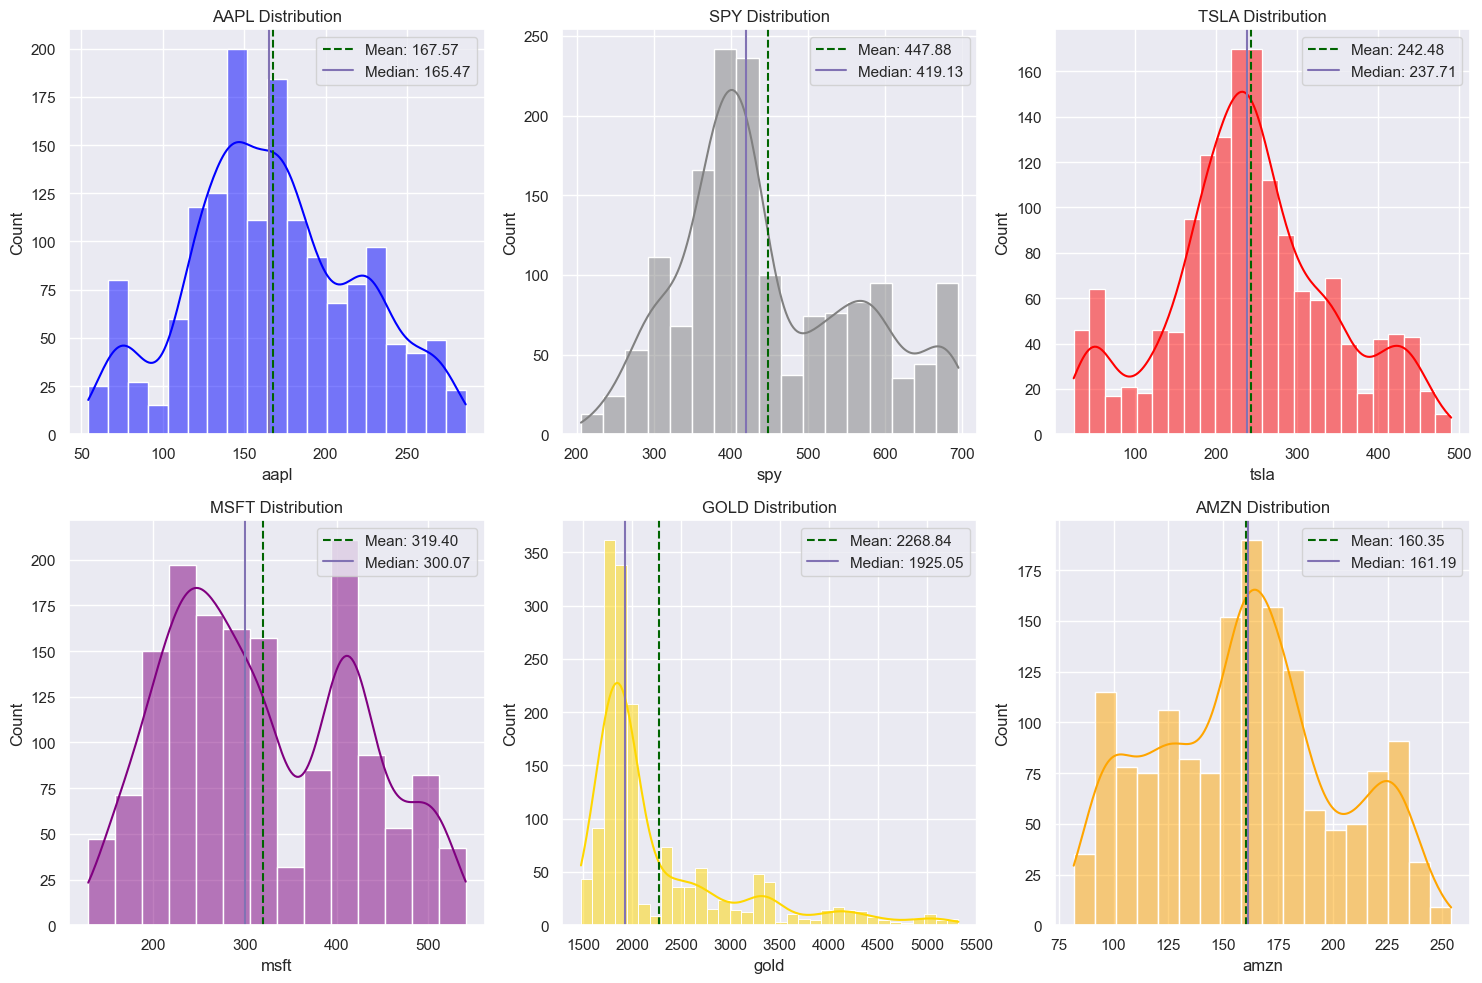

In [10]:
# 1. Create a 2x3 grid for the 6 stocks
fig, axes = plt.subplots(2, 3, figsize=(15, 10)) 

# 2. Flatten the 2D axes array into 1D for easy iteration
axes = axes.flatten() 

# 3. Define the data columns, titles, and unique colors for each chart
stocks = ['aapl', 'spy', 'tsla', 'msft', 'gold', 'amzn']
titles = ['AAPL Distribution', 'SPY Distribution', 'TSLA Distribution', 'MSFT Distribution', 'GOLD Distribution', 'AMZN Distribution']
colors = ['blue', 'grey', 'red', 'purple', 'gold', 'orange'] # Unique colors for each plot

# 4. Loop through the lists using enumerate to get both index (i) and stock name
for i, stock in enumerate(stocks):

    # Draw the histogram using a specific color from our list 
    sns.histplot(data=df_final, x=stock, kde=True, ax=axes[i], color=colors[i])

    # Calculate statistical metrics for the current stock
    mean_val = df_final[stock].mean()
    median_val = df_final[stock].median()

    # Add a dashed red line for the Mean
    axes[i].axvline(mean_val, color='darkgreen', linestyle='--', label=f'Mean: {mean_val:.2f}')

    # Add a solid line for the Median (using white or black for contrast)
    axes[i].axvline(median_val, color='m', linestyle='-', label=f'Median: {median_val:.2f}')

    # Set the subplot title and show the legend
    axes[i].set_title(titles[i])
    axes[i].legend()

# 5. Clean up the layout to prevent text overlapping
plt.tight_layout()

# 6. Display the final dashboard
plt.show()

**1. Symmetric Distributions (AAPL, AMZN, TSLA)**

The price spends most of its time near the average.
Standard Deviation works best here: You can use "Normal Distribution" rules (like the 68-95-99.7 rule) to predict where the price will likely be tomorrow with decent accuracy, so These stocks are currently trading in a "balanced" range without extreme outliers pulling the average away.

**2. Right Skewed Distributions (SPY, GOLD)**

Right skew means there are a few instances of extremely high prices that pull the average up, even though most of the data is lower.
Because the mean is higher than the median, the "average" price is being inflated by outliers. If those outliers disappear, the price often "falls back" toward the median.

- For **GOLD** specifically, the median is a much more "realistic" representation of where the price usually sits than the mean.

**3. Bimodal Distributions (MSFT)**

When you see two "humps" (like MSFT), it usually means the stock has two "fair value" zones. It recently moved from a lower price regime to a higher one.

- The "Mean" here is actually misleading, we will depend on the median.

##### **Now we want to know about price movements**

In [11]:
# Plot only those columns
fig = px.line(data_frame=df_final)

# Make it look clean
fig.update_layout(
    title='Interactive Portfolio Price Explorer',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
)

fig.show(config={'displayModeBar': False})

*We need to observe the movement stock (How much the stock went up or down compared to the others), therefore we need to Normalize the prices of stocks to start with $1, and to do this we will* **devide the prices of each column by day One**

In [12]:
# 2. Perform the normalization
norm = df_final / df_final.iloc[0, :]
# 3. View the results
norm.head()

,aapl,tsla,msft,gold,spy,amzn
Date,,,,,,
2020-01-02,1.00,1.00,1.00,1.00,1.00,1.00
2020-01-03,0.99,1.03,0.99,1.02,0.99,0.99
2020-01-06,1.00,1.05,0.99,1.03,1.00,1.00
2020-01-07,0.99,1.09,0.98,1.03,0.99,1.00
2020-01-08,1.01,1.14,1.00,1.02,1.00,1.00


**Plotting normalization**

In [13]:
fig = px.line(norm)
fig.update_layout(title='Stock movement observation by normalizing Adj close prices',
                  xaxis_title='Year', yaxis_title='Normalized price')
fig.show(config={'displayModeBar': False}) # this line to remove the mess like the camera and zoom and these symbols at the top left

**TSLA** is described as very **volatile**.
Over the last five years, TSLA has consistently shown a much higher standard deviation of returns compared to "safe-haven" tech stocks. Its price is heavily influenced by rapid growth expectations, earnings misses, and even social media sentiment.

**Microsoft & Apple** follow similar patterns because they are both Mega-Cap Tech stocks in the same sector. When the "tech sector" goes up or down, they move in tandem due to index fund buying.

**Gold** spent several years in a sideways range but surged in late 2025 and 2026, hitting record highs above $3,000–$4,000 per ounce.
Central banks in emerging markets have shifted from buying US Treasuries to buying Gold at record rates, providing the "fuel" for this 2026 breakout.


---------------------------------------------

##### **bollinger bands indicator  To determine the entry and exit point**


**Simple Moving Average**

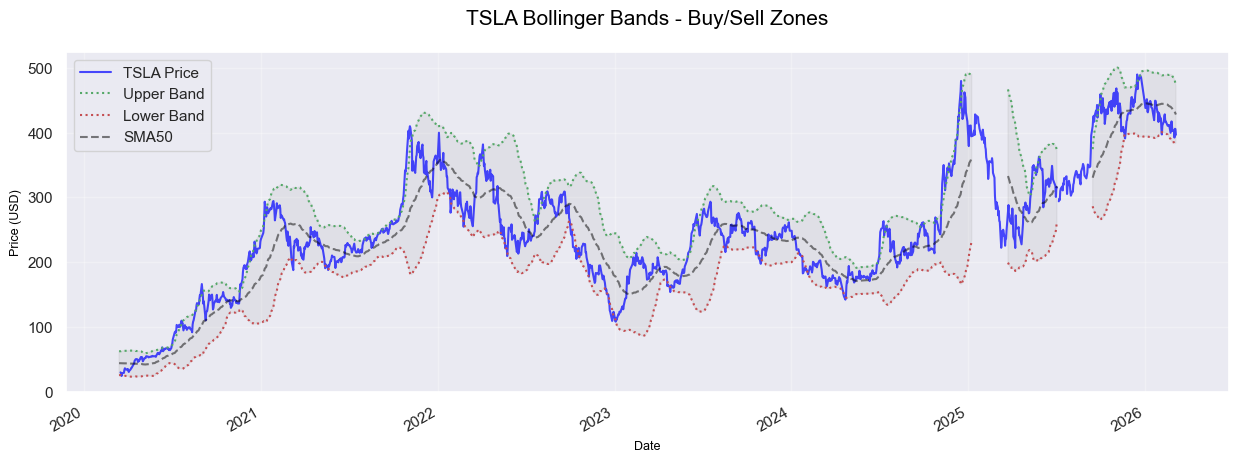

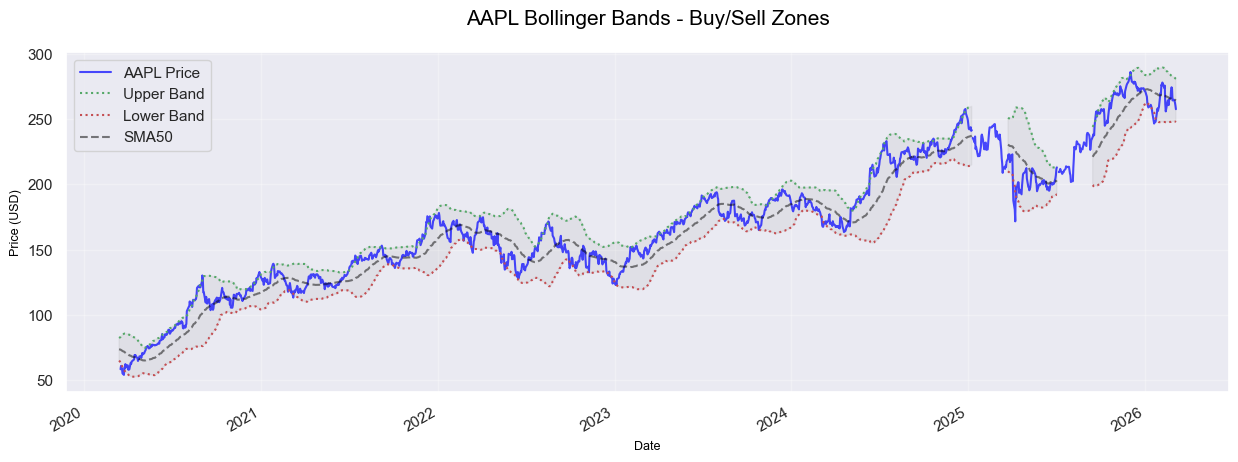

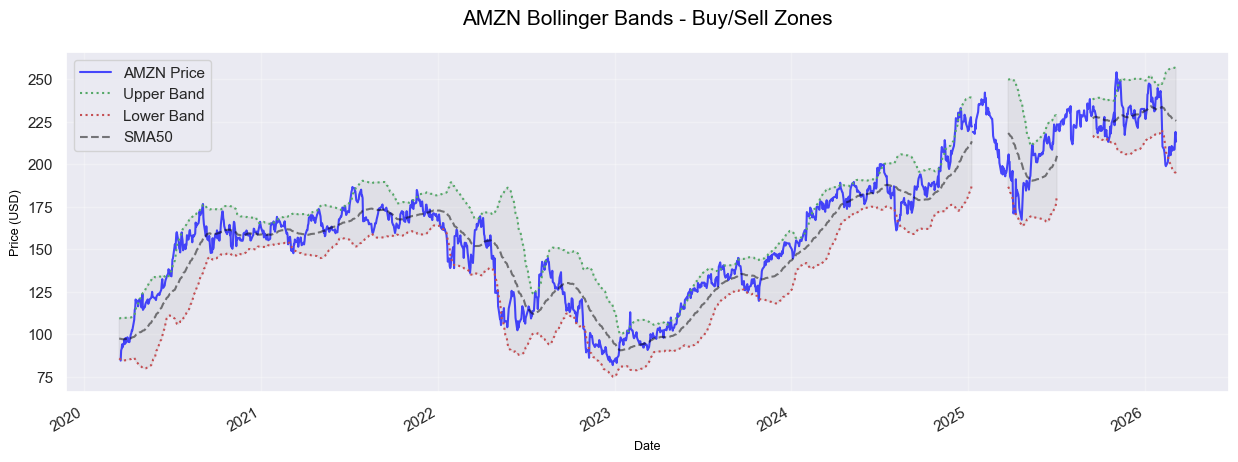

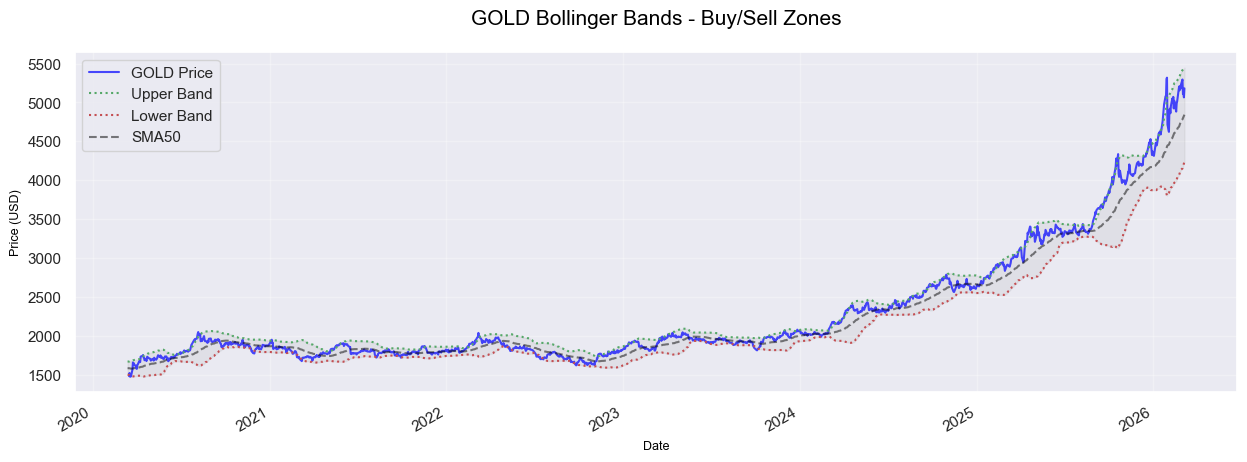

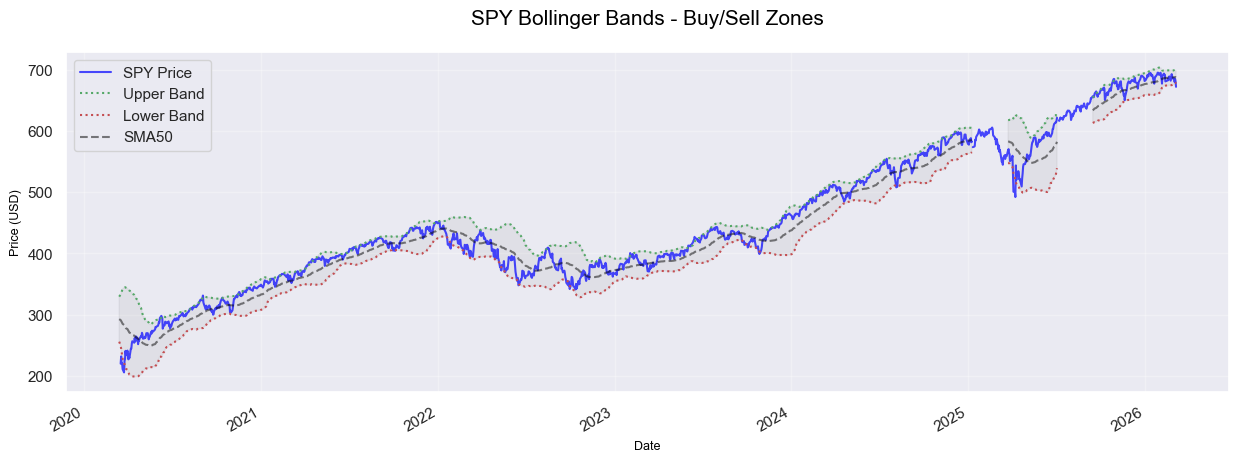

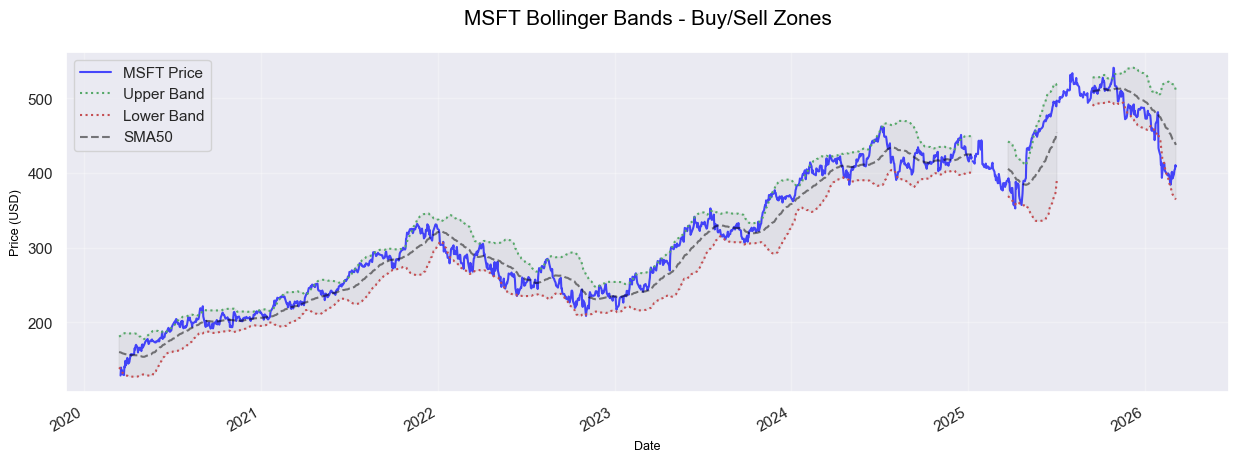

In [14]:
# 1. List the stocks you want to analyze
stocks = ['tsla', 'aapl', 'amzn', 'gold', 'spy', 'msft'] 

# 2. Start the loop
for stock in stocks:
    # Calculate indicators dynamically for each 'stock'
    rollingmean = df_final[stock].rolling(50).mean()
    rollingstd = df_final[stock].rolling(50).std()
    upper_band = rollingmean + (rollingstd * 2)
    lower_band = rollingmean - (rollingstd * 2)
    # Create a new figure for each stock
    fig, ax = plt.subplots(figsize=(15, 5))
    # Plot the Actual Price (starting from day 50 to avoid the empty 'warm-up' period)
    df_final.iloc[50:][stock].plot(ax=ax, label=f'{stock.upper()} Price', color='blue', alpha=0.7)  
    # Plot the Bollinger Bands
    upper_band.plot(ax=ax, color='g', linestyle=':', label='Upper Band')
    lower_band.plot(ax=ax, color='r', linestyle=':', label='Lower Band')
    rollingmean.plot(ax=ax, color='black', linestyle='--', label='SMA50', alpha=0.5)

    # Fill the "Safe Zone"
    ax.fill_between(df_final.index, lower_band, upper_band, color='gray', alpha=0.1)

    # Style the chart using your custom function
    style_labels_and_title(ax, 
                           x_label='Date', 
                           y_label='Price (USD)', 
                           title=f'{stock.upper()} Bollinger Bands - Buy/Sell Zones')
    
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show() # This ensures each chart is displayed before the next loop starts

**Gold** Market **Volatility** & Trend Analysis(2020 – 2026)

 - Since late **2023**, Gold has consistently traded above the **SMA50** (Gray Dashed Line), confirming a sustained long-term uptrend.

 - The widening of the **Bollinger Bands in 2025–2026 **indicates a significant increase in market volatility compared to the 2021 consolidation period.

 - Recent price action "hugging" the Upper Band (Green) suggests an overextended market with a high probability of a short-term pullback.

 - Historical data shows the Lower Band (Red) acts as a reliable "**Buy Zone**" during mean-reversion events.




$\color{gray}{\text{The Middle (SMA50)}}$: This is the Mean. It tells you the direction of the trend.

The Bounds ($\color{green}{\text{Upper}}$/$\color{red}{\text{Lower}}$): These are the Standard Deviations. They tell you the "Normal Range" of the stock.

The Squeeze: When the Upper and Lower bands get very close to each other, it means volatility is low.

------------------------------

### - **Metrics**

- Daily Returns
- Cummulative Returns
- Sharpe Ratio
- Kurtosis

$\color{orange}{\text{Daily returns ratio}}$: is how much did the price go up or down on a particular day

                        DailyReturn(t) = (price[t]/price[t-1]) - 1

In [15]:
df_final.head()

,aapl,tsla,msft,gold,spy,amzn
Date,,,,,,
2020-01-02,72.40,28.68,152.51,"1,524.50",297.70,94.90
2020-01-03,71.70,29.53,150.61,"1,549.20",295.44,93.75
2020-01-06,72.27,30.10,151.00,"1,566.20",296.57,95.14
2020-01-07,71.93,31.27,149.62,"1,571.80",295.74,95.34
2020-01-08,73.09,32.81,152.00,"1,557.40",297.31,94.60


- You can get the result using ****pct_change**** function

In [16]:
df_final.ffill() # This ensures that if a stock price is missing for a day, it uses the last known price. This prevents "fake" zeros or errors in your returns.
daily_returns = df_final.pct_change(fill_method=None)
daily_returns.iloc[0,:] = 0
daily_returns.head()

,aapl,tsla,msft,gold,spy,amzn
Date,,,,,,
2020-01-02,0.00,0.00,0.00,0.00,0.00,0.00
2020-01-03,-0.01,0.03,-0.01,0.02,-0.01,-0.01
2020-01-06,0.01,0.02,0.00,0.01,0.00,0.01
2020-01-07,-0.00,0.04,-0.01,0.00,-0.00,0.00
2020-01-08,0.02,0.05,0.02,-0.01,0.01,-0.01


The sign of the daily return tells you the direction of the **price movement** relative to the previous day:

**Positive** (+) Value: The closing price today was higher than the closing price yesterday. The stock gained value.

**Negative** (-) Value: The closing price today was lower than the closing price yesterday. The stock lost value.

**Zero** (0.0): The price remained exactly the same as the previous trading day.

**50% (The Median)**: This is the middle value. For all your stocks, it is 0.00. This means that on 50% of days, the stock basically didn't move or had a tiny gain.

**25%** (The Bad Days): 25% of the time (1 out of every 4 days), TSLA loses 2% (-0.02) or more.

**75%** (The Good Days): 75% of the time, AAPL and MSFT returns are below 1% (0.01). Only the top 25% of days see gains higher than that.

**TSLA is the Outlier**: Its standard deviation is 0.04, double that of AAPL (0.02) and four times that of SPY (0.01). This confirms what you saw in your histograms: the distribution is much wider.

**SPY and GOLD** are the "Anchors": They have the smallest std (0.01) and the narrowest min/max range. They are much less likely to give you a "surprise" (outlier) than the individual tech stocks.

In [17]:
daily_stats = daily_returns.describe().T
# Export to a professional Excel file
daily_stats.to_excel("Financial_Analysis_Results.xlsx", sheet_name="Daily_Returns_Stats")

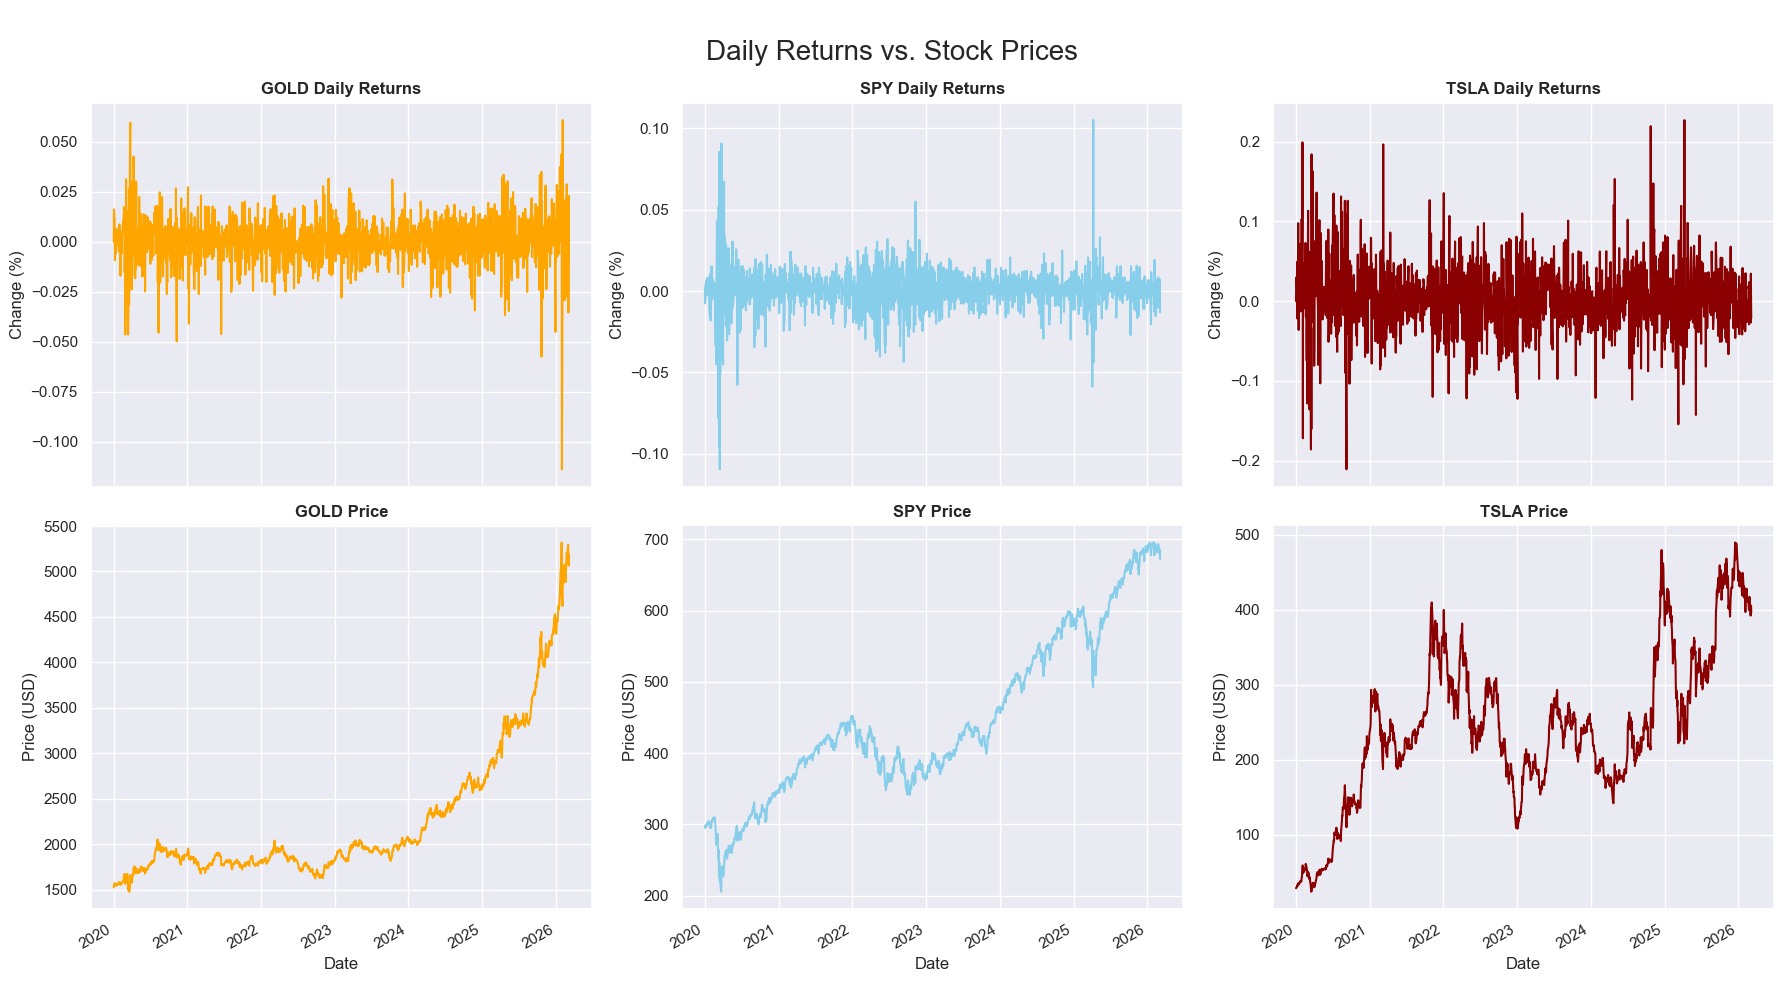

In [18]:
# Create a figure with a 2x3 grid (2 rows, 3 columns) 
# sharex=True ensures all charts in a column use the same Date axis at the bottom
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

# Define custom colors for better visualization (Gold=Orange, Tesla=Red, etc.)
colors = {'gold': 'orange', 'spy': 'skyblue', 'tsla': 'darkred'}
stocks = ['gold', 'spy', 'tsla']

# Loop through our 3 chosen assets to fill the columns
for i, stock in enumerate(stocks):
    
    # --- ROW 1: VOLATILITY ANALYSIS ---
    # Plot the percentage change (Daily Returns) in the top row
    daily_returns[stock].plot(ax=ax[0][i], color=colors[stock])
    ax[0][i].set_title(f'{stock.upper()} Daily Returns', fontweight='bold')
    ax[0][i].set_ylabel('Change (%)') # Helpful for the viewer to know what the Y-axis is
    
    # --- ROW 2: PRICE TREND ANALYSIS ---
    # Plot the raw closing prices in the bottom row
    df_final[stock].plot(ax=ax[1][i], color=colors[stock])
    ax[1][i].set_title(f'{stock.upper()} Price', fontweight='bold')
    ax[1][i].set_ylabel('Price (USD)')

# Set a large, centered main title for the entire dashboard
fig.suptitle('\nDaily Returns vs. Stock Prices', fontsize=20)

# Automatically adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

**1. The Stability of GOLD (The "Safe Haven")** Look at the Gold Price chart. It shows a massive, steady climb starting around 2024.
 While the price is climbing, the "Daily Returns" chart above it stays relatively "quiet" (the spikes aren't as long as TSLA).
 Gold is acting as the "steady engine." It's gaining value without giving the investor a heart attack every morning.

**2. The TSLA Rollercoaster (The "Growth Aggressor")**
TSLA has the tallest "spikes" in the Daily Returns row. It moves up and down by huge percentages in a single day.
Notice the "cluster" of volatility in early 2021. The price chart below it shows a vertical climb followed by a crash.

**3. SPY: The "Market Mirror"**
SPY (The S&P 500) shows a very consistent upward trend.
Its returns are "tighter" than TSLA but more active than Gold. It represents the overall health of the economy.
If SPY is going up and TSLA is going down, TSLA has a "Company Problem." If both are going down, the "Whole World" has a problem.

---------------------------

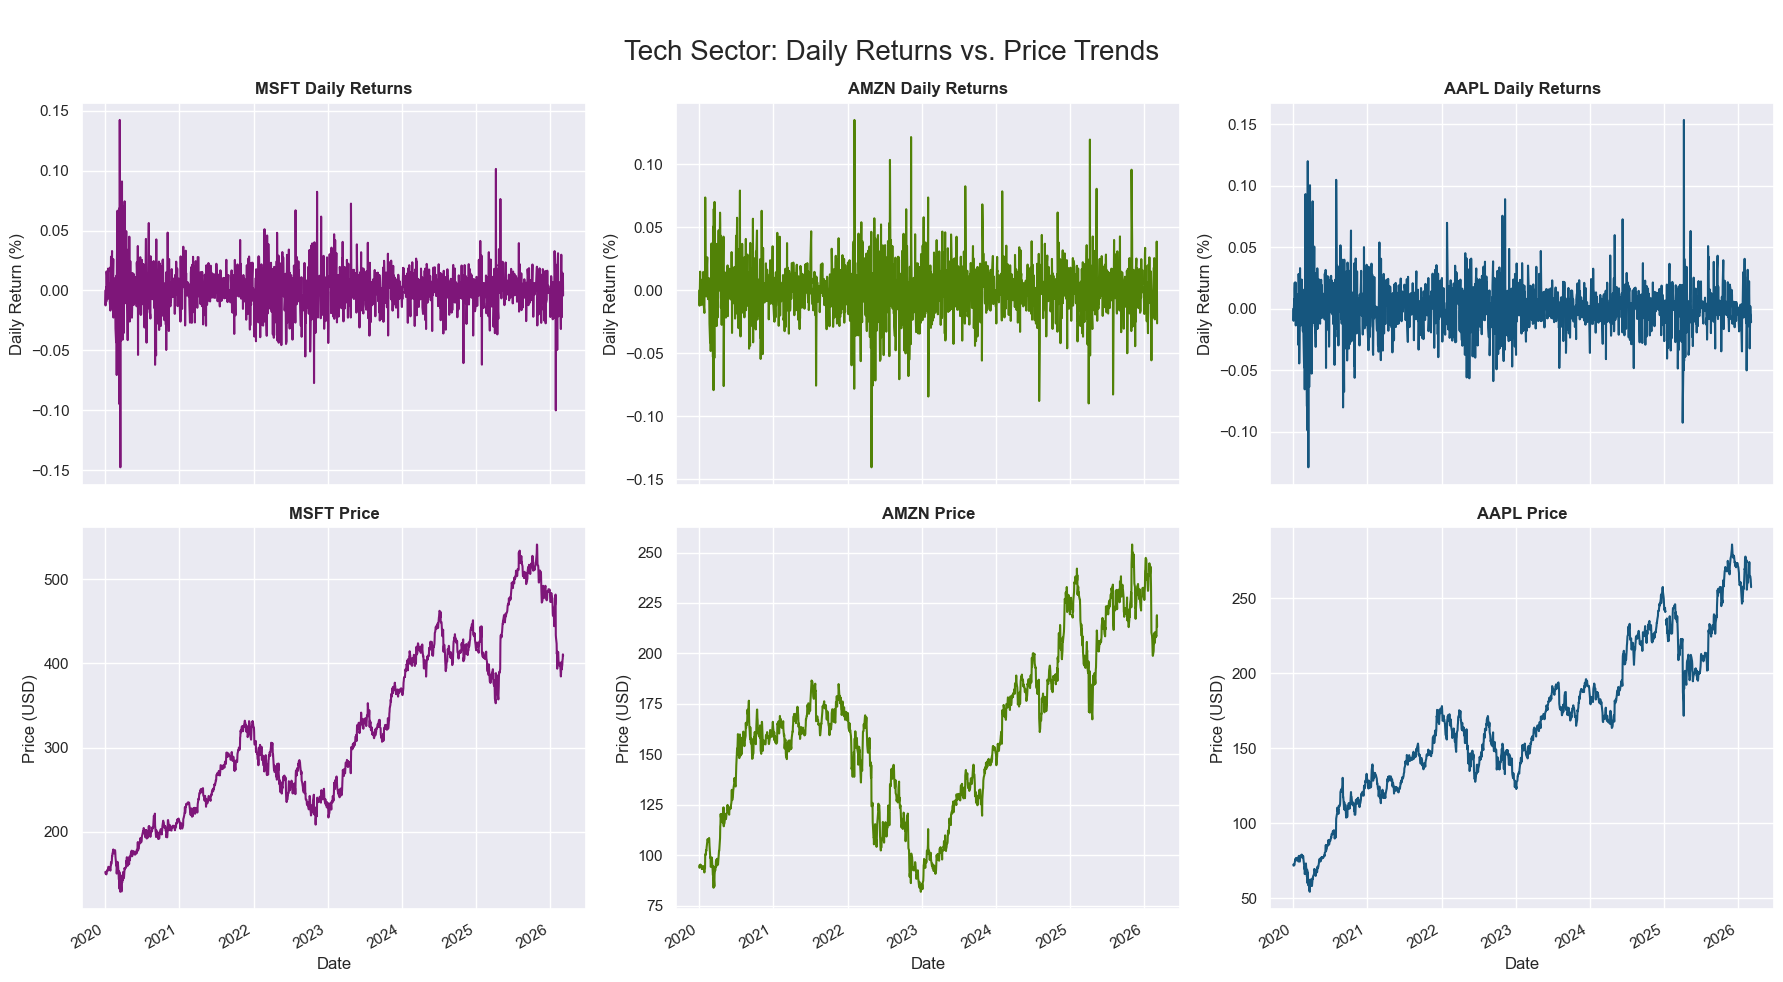

In [19]:
# Initialize a 2x3 subplot grid for the Tech Sector analysis
# We use sharex=True so the time (X-axis) stays perfectly aligned for all 6 charts
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

# Assigning professional hex color codes for brand consistency 
# (Purple for MSFT, Green for AMZN, Blue for AAPL)
colors = {'msft': "#7E1679", 'amzn': "#518207", 'aapl':"#16567E"}
stocks = ['msft', 'amzn', 'aapl']

# Iterate through each tech stock to populate the columns
for i, stock in enumerate(stocks):
    
    # --- TOP ROW: VOLATILITY & RISK ---
    # Plotting percentage changes to show day-to-day market sentiment
    daily_returns[stock].plot(ax=ax[0][i], color=colors[stock])
    ax[0][i].set_title(f'{stock.upper()} Daily Returns', fontweight='bold')
    ax[0][i].set_ylabel('Daily Return (%)') 
    
    # --- BOTTOM ROW: PRICE ACCUMULATION ---
    # Plotting historical closing prices to show the overall growth trend
    df_final[stock].plot(ax=ax[1][i], color=colors[stock])
    ax[1][i].set_title(f'{stock.upper()} Price', fontweight='bold')
    ax[1][i].set_ylabel('Price (USD)')

# Global Title to unify the tech sector visualization
fig.suptitle('\nTech Sector: Daily Returns vs. Price Trends', fontsize=20)

# Clean up layout to prevent overlapping of labels and titles
plt.tight_layout()
plt.show()

MSFT & AAPL: Look at the "Daily Returns" (top row). You see those spikes going down to -0.10 or -0.15? That means even these "safe" stocks had days where they lost 10-15% of their value in 24 hours.

The Illusion of Safety: They look smoother on the bottom price chart because they have grown so much, but the top chart shows they still "shake" quite a bit.

While Microsoft, Apple, and Amazon are industry **titans**, their charts reveal a shared vulnerability. In late 2022 and early 2023, all three experienced a **significant drawdown**. This wasn't due to poor management, but rather a **shifting macroeconomic climate—specifically** rising interest rates that pressured the entire tech sector.

AMZN showed the highest **volatility**, dropping to nearly $80 in 2023. While it recovered, investors who panicked at the bottom "lost" money, highlighting that Amazon is a higher-beta (more sensitive) stock than its peers.

Even "stable" picks like AAPL and MSFT saw daily swings of over 5%. 
By 2024, the narrative shifted toward AI and Cloud growth, allowing all three to reach new highs, proving that for Big Tech, the 2023 dip was a hurdle, not a finish line.

---------------

$\color{orange}{\text{Cumulative returns ratio}}$: is the **Profit/Loss** ratio of the stock on a particular period

                    CR(t) = (price[t]/price[0]) - 1
                                         

                                OR

                  CR(t) = (price[t]-price[0])price[0]

In [20]:
stocknames = df_final.columns
for stock in stocknames:
   print('Cumulative return of {} is: {}%'.format(stock, round(((df_final.iloc[-1][stock] / df_final.iloc[0][stock]) - 1) * 100, 2)))

Cumulative return of aapl is: 255.61%
Cumulative return of tsla is: 1283.11%
Cumulative return of msft is: 168.16%
Cumulative return of gold is: 239.87%
Cumulative return of spy is: 125.86%
Cumulative return of amzn is: 124.67%


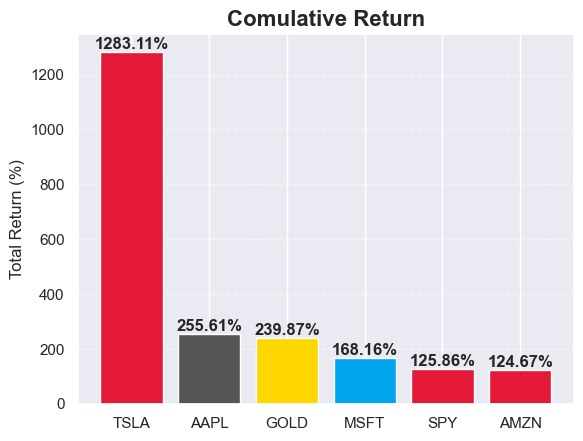

In [21]:
# 1. Calculate the returns and store them in a dictionary
returns_dict = {}
for stock in df_final.columns:
    ret = ((df_final.iloc[-1][stock] / df_final.iloc[0][stock]) - 1) * 100
    returns_dict[stock.upper()] = round(ret, 2)
# 2. Convert to a Series and sort them
returns_series = pd.Series(returns_dict).sort_values(ascending=False)

# 3. Plotting
# plt.figure(figsize=(10, 6))
colors = ['#FFD700' if x == 'GOLD' else '#00A4EF' if x == 'MSFT' else '#555555' if x == 'AAPL' else '#E31937' for x in returns_series.index]
bars = plt.bar(returns_series.index, returns_series.values, color=colors)

# 4. Add the percentage labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontweight='bold')

plt.title('Comulative Return', fontsize=16, fontweight='bold')
plt.ylabel('Total Return (%)')
plt.axhline(0, color='black', linewidth=0.8) # Zero line
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**The Tesla Outlier**: TSLA’s return is the "main character" of this dataset. It outperformed the broader market (SPY) by more than 10x. This suggests that while it may be the most volatile, the "risk premium" paid off significantly for long-term holders.

**Gold’s Surprise**: Seeing Gold like that is fascinating. It outperformed Microsoft and Amazon, likely acting as a safe haven during the high-inflation periods and interest rate hikes we discussed earlier.

**Apple vs. Microsoft**: Apple nearly doubled the total returns of Microsoft, showing that despite being similar "safe" stocks, Apple's capital appreciation was much more aggressive.

----------------

$\color{orange}{\text{Sharpe Ratio}}$: The Sharpe Ratio is the ultimate "Efficiency Metric." In the investing world, it’s not just about how much money you made, but how much stress (volatility) you had to endure to get those returns.

this is the number that tells the client: "Is this stock actually worth the risk?"

Sharpe > 1: Good.

Sharpe > 2: Very Good (High efficiency).

Sharpe > 3: Excellent.

To calculate it, we use this formula:

                Sharpe Ratio = (Rp - Rf) / sigma_p

Rp: Expected Portfolio Return (Mean of daily returns).

Rf: Risk-Free Rate (Usually the return on a "safe" Govt Bond, often assumed as 0 in basic projects).

sigma_p: Standard Deviation (Risk/Volatility).        

Since we already have your daily_returns dataframe, we can calculate the Annualized Sharpe Ratio for all our assets in just a few lines. We multiply by $\sqrt{252}$ because there are 252 trading days in a year.

In [35]:
# 1. Calculate Mean Daily Return
mean_ret = daily_returns.mean()

# 2. Calculate Daily Standard Deviation (Risk)
std_dev = daily_returns.std()

# 3. Calculate Annualized Sharpe Ratio (Assuming Risk-Free Rate = 0)
sharpe_ratio = (mean_ret / std_dev) * np.sqrt(252)

# 4. Display as a nice sorted list
print(sharpe_ratio.sort_values(ascending=False))

gold   1.17
tsla   0.99
aapl   0.83
spy    0.77
msft   0.70
amzn   0.55
dtype: float64


1. Gold (1.18) is the Winner
What it means: For every 1 unit of "risk" (volatility) taken, Gold returned 1.18 units of profit.

The Insight: Gold isn't just a "safe haven"; in your specific data period, it provided the most "efficient" growth. It had the best balance of steady gains without the massive heart-attack swings of tech stocks.

2. TSLA (1.00) vs. MSFT (0.68)
The Trap: Tesla likely had much higher total returns than Microsoft. However, because Tesla's price swings are so violent (high standard deviation), its Sharpe Ratio is lower than it "should" be.

The Comparison: Even though Tesla is at 1.00, Microsoft at 0.68 tells us that Microsoft was much "shakier" relative to the small gains it provided during this specific window.

Notice the SPY is right in the middle. Most professional fund managers aim to beat the Sharpe Ratio of the SPY. Since Gold, TSLA, and AAPL all have higher Sharpe Ratios than the SPY, they were "Smart" additions to the portfolio. AMZN (0.55), however, underperformed the market's efficiency.

**"While Tesla provided high absolute returns, my Sharpe Ratio analysis proves that Gold was the most efficient asset, offering a 1.18 risk-adjusted return. This suggests that a diversified portfolio including Gold would have provided superior stability compared to a pure tech-play."**

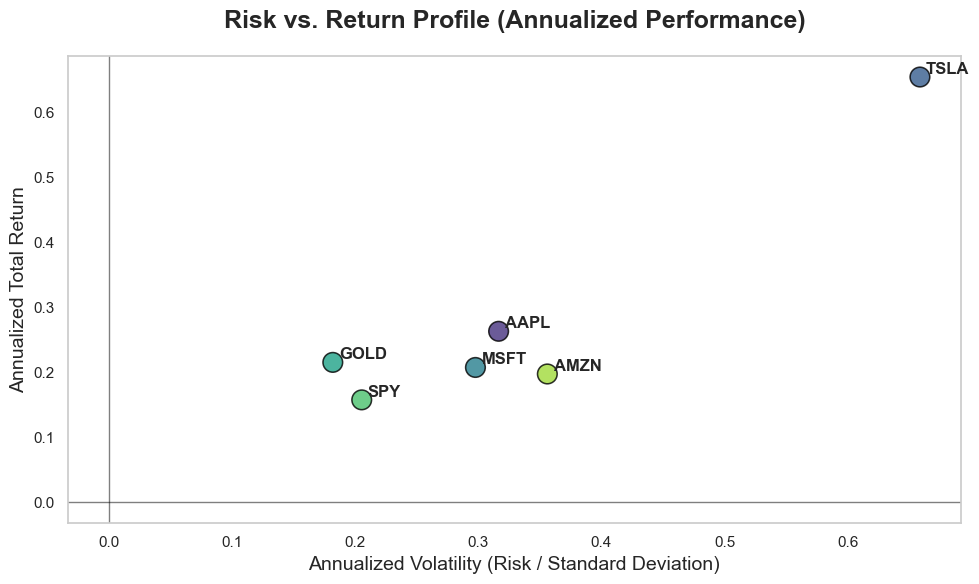

In [23]:
# 1. Calculate Annualized Metrics
annual_return = daily_returns.mean() * 252
annual_risk = daily_returns.std() * np.sqrt(252)

# 2. Create a Summary DataFrame
risk_return_df = pd.DataFrame({
    'Risk': annual_risk,
    'Return': annual_return,
    'Asset': annual_risk.index
})

# 3. Create the Scatter Plot
sns.set_style("whitegrid")

# Added 'legend=False' here to remove the top-right box
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=risk_return_df, 
    x='Risk', 
    y='Return', 
    hue='Asset', 
    palette='viridis',
    edgecolor='black',
    alpha=0.8,
    s=200,          # Increased size for better visibility
    legend=False    # <--- This removes the legend
)

# 4. Add Labels to each point (Stock Tickers)
for i in range(len(risk_return_df)):
    plt.text(
        risk_return_df['Risk'].iloc[i] + 0.005, 
        risk_return_df['Return'].iloc[i] + 0.005, 
        risk_return_df['Asset'].iloc[i].upper(), 
        fontsize=12, 
        fontweight='bold'
    )

# 5. Formatting the Chart
plt.title('Risk vs. Return Profile (Annualized Performance)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Annualized Volatility (Risk / Standard Deviation)', fontsize=14)
plt.ylabel('Annualized Total Return', fontsize=14)

# Keep the center lines but remove the grid as requested
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.axvline(0, color='black', linewidth=1, alpha=0.5)
plt.grid(False)

plt.tight_layout()
plt.show()

"The Risk vs. Return profile reveals a clear divergence in asset efficiency. While TSLA offers the highest absolute returns, it carries extreme volatility. Conversely, GOLD emerges as the most efficient diversifier, providing superior returns to AMZN and MSFT while maintaining significantly lower risk. For a balanced portfolio, the data suggests that AAPL and GOLD provide the best risk-adjusted value compared to the broader market (SPY)."

-------------------

$\color{orange}{\text{Kurtosis}}$ :  measures the presence of outliers by evaluating the "tailedness" of a probability distribution

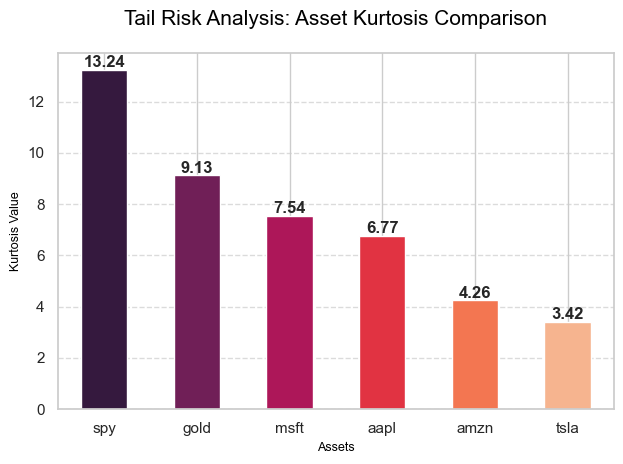

In [24]:
# 1. Calculate Kurtosis for all stocks
kurt_values = daily_returns.kurtosis().sort_values(ascending=False)

# 2. Create the Bar Chart
colors = sns.color_palette("rocket", len(kurt_values)) # Darker red for higher risk
ax = kurt_values.plot(kind='bar', color=colors)

# # 3. Professional Formatting
style_labels_and_title(ax=ax, title='Tail Risk Analysis: Asset Kurtosis Comparison', y_label='Kurtosis Value', x_label='Assets')
plt.xticks(rotation=0) # Keeps stock names horizontal and easy to read
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of each bar
for i, v in enumerate(kurt_values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Kurtosis_Comparison.png')
plt.show()

**SPY '13.22' Extreme Outlier Sensitivity**: This is the highest. It means SPY (the S&P 500) has the most "Black Swan" events (like the 2020 COVID crash). When SPY moves, it sometimes moves with massive, unexpected force.

**GOLD '9.33' Significant Tail Risk**: Gold is generally "quiet," but this high number shows that when it does break its trend, it does so with very sharp, sudden spikes or drops (like the -0.100 move you spotted in 2026).

**MSFT / AAPL '7.58 / 6.76' High Outlier Frequency**: These tech giants have frequent earnings-related gaps. They aren't as "extreme" as SPY, but they still have significant "fat tails.

"**AMZN / TSLA 4.27 / 3.40 Relatively Stable Shape**: Surprisingly, TSLA has the lowest kurtosis here. This means TSLA's volatility is "consistent." It moves a lot every day, so a big move is "normal" for Tesla, whereas a big move for SPY is a "shock."

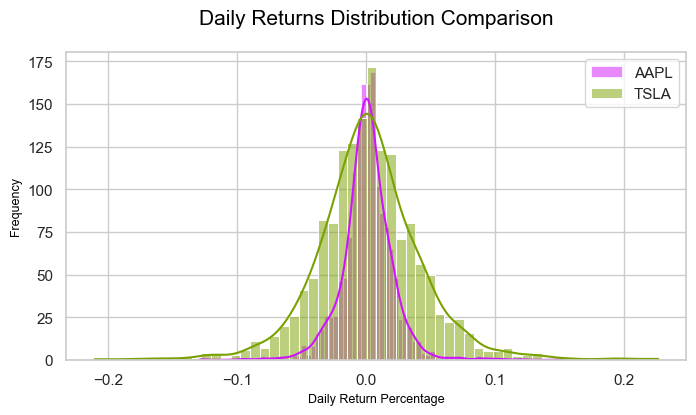

In [25]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(daily_returns['aapl'], kde=True, color="#D013FF", label='aapl'.upper())
sns.histplot(daily_returns['tsla'], kde=True, color="#79A100", label='tsla'.upper())

style_labels_and_title(ax=ax, title='Daily Returns Distribution Comparison', 
                       x_label='Daily Return Percentage', y_label='Frequency')
plt.legend()
plt.show()

Look at the green curve for TSLA. It is much flatter and wider than the aapl. it proves that TSLA has a much higher probability of extreme price swings on any given day. TSLA has visible "tails" reaching beyond +20% and -20% daily return percentage. This confirms that while it can offer high profit, the risk of a massive sudden drop is much higher.

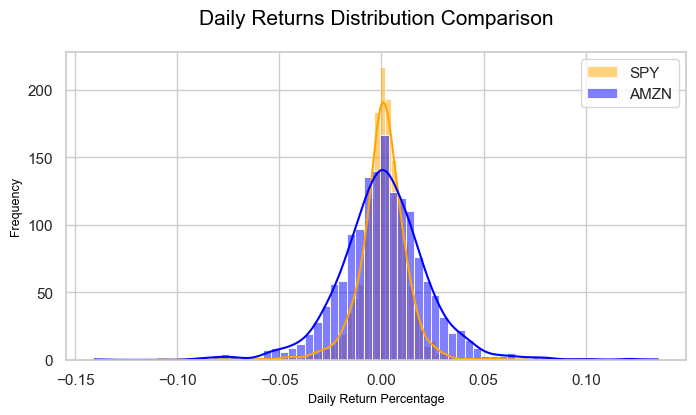

In [26]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(daily_returns['spy'], kde=True, color='orange', label='spy'.upper())
sns.histplot(daily_returns['amzn'], kde=True, color='blue', label='amzn'.upper())

style_labels_and_title(ax=ax, title='Daily Returns Distribution Comparison', 
                       x_label='Daily Return Percentage', y_label='Frequency')
plt.legend()
plt.show()

*Comparing AMZN to SPY highlights the difference between individual stock risk and market index stability. AMZN exhibits significant 'fat tails' and outliers, with the potential for daily returns as extreme as -15% or +10%. Meanwhile, SPY remains tightly centered, representing a much lower-risk investment with fewer extreme outliers.*

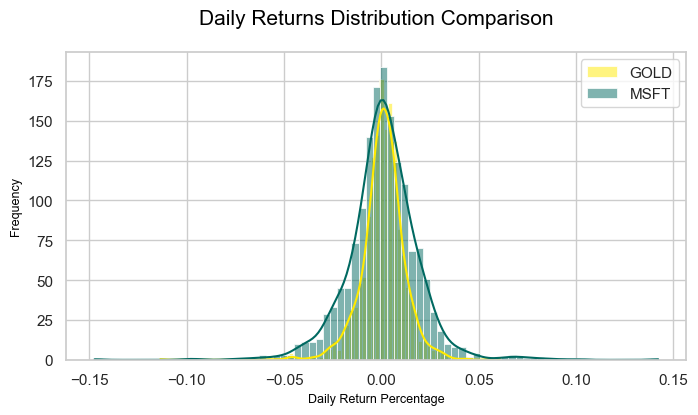

In [27]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(daily_returns['gold'], kde=True, color="#FFEA00", label='gold'.upper())
sns.histplot(daily_returns['msft'], kde=True, color="#006961", label='msft'.upper())

style_labels_and_title(ax=ax, title='Daily Returns Distribution Comparison', 
                       x_label='Daily Return Percentage', y_label='Frequency')
plt.legend()
plt.show()

*Comparing the distributions of GOLD and MSFT reveals a clear trade-off between stability and growth. MSFT exhibits significant outliers and 'fat tails,' with daily returns occasionally swinging to ±15%. This indicates a higher risk profile. GOLD, conversely, maintains a tight distribution centered around zero with a much smaller range of ±5%, making it a safer, lower-volatility hedge for the portfolio.*

#### **Correlations**

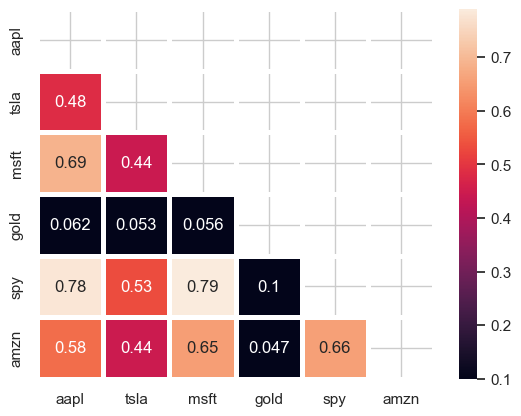

In [28]:
# 1. Create a matrix of zeros the same size as our correlation table
mask = np.zeros_like(daily_returns.corr())

# 2. Fill the "Upper Triangle" of that matrix with 'True' (1s)
# This tells Seaborn: "Hide the data where mask is True"
mask[np.triu_indices_from(mask)] = True

# 3. Create the heatmap
sns.heatmap(
    daily_returns.corr(), # The data (Correlation matrix)
    annot=True,           # Write the numbers inside the boxes
    vmin=0.1,             # Set the anchor for the darkest color at 0.1
    mask=mask,            # Apply the triangle mask to hide the top half
    linewidths=2.5        # Add the white borders between squares for style
);

The correlation analysis confirms that the **SPY** is heavily influenced by **MSFT** (0.79) and **AAPL** (0.78). Conversely, **Gold** shows near-zero correlation with tech assets, highlighting its effectiveness as a portfolio diversifier to mitigate systemic equity risk.

-------

**How much do Apple and Microsoft move the needle for the SPY? Let’s look at the correlation through these regression trends.**

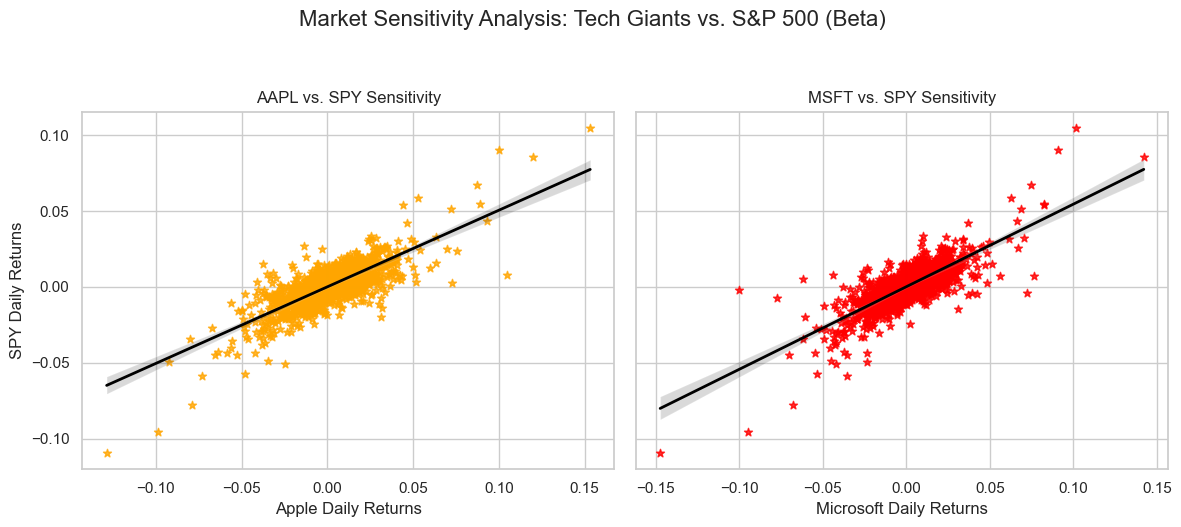

In [29]:
# Create the figure with shared Y-axis (SPY)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot 1: Apple vs. SPY
sns.regplot(data=daily_returns, x='aapl', y='spy', 
            scatter=True, marker='*', ax=ax[0], color='orange', 
            line_kws={"color": "black", "lw": 2}) # Added a black trend line for clarity
ax[0].set_title('AAPL vs. SPY Sensitivity')
ax[0].set_xlabel('Apple Daily Returns')
ax[0].set_ylabel('SPY Daily Returns')

# Plot 2: Microsoft vs. SPY
sns.regplot(data=daily_returns, x='msft', y='spy', 
            scatter=True, marker='*', ax=ax[1], color='red',
            line_kws={"color": "black", "lw": 2})
ax[1].set_title('MSFT vs. SPY Sensitivity')
ax[1].set_xlabel('Microsoft Daily Returns')
ax[1].set_ylabel('') # Hide Y label on the second plot since it's shared

# Add a professional main title
plt.suptitle('Market Sensitivity Analysis: Tech Giants vs. S&P 500 (Beta)', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

You see how strongly **AAPL** and **MSFT** are tied to the **SPY**! These regression plots show exactly how much the tech giants drive the overall market.

-------

*Cooficient Correlation and Pvalue using Scipy:*

In [30]:
daily_returns = daily_returns.dropna()
# 1. This function calculates two things at once:  The strength (coff) and the mathematical certainty (pval).
coff, pval = stats.pearsonr(daily_returns.aapl, daily_returns.spy)
print('Correlation AAPL/SPY = {:.4f}'.format(coff), 'P-value = {:.4e}'.format(pval))

coff, pval = stats.pearsonr(daily_returns.msft, daily_returns.spy)
print('Correlation MSFT/SPY = {:.4f}'.format(coff), 'P_value = {:.4e}'.format(pval))

Correlation AAPL/SPY = 0.7785 P-value = 1.6330e-315
Correlation MSFT/SPY = 0.7893 P_value = 0.0000e+00


With a P-value this low, the correlation between **Apple** and the **SPY** is a statistically significant certainty. This is not a coincidence or a "lucky" trend—it is a proven scientific fact backed by 6 years of historical data.

**coff (The Correlation Coefficient)**: This is the same number we saw in the heatmap (e.g., 0.78).
 It tells us the strength and direction of the relationship between Apple and the S&P 500. 
 

- Range: -1 to +1. 
- Your Case: Since it's around 0.78, it means they have a very strong positive relationship.

**pval (The P-Value)**: This is the most important part for a Data Scientist.
 It tells you: "Is this relationship real, or just a lucky coincidence?"
  
- The Rule of Gold: If pval is less than 0.05, the result is "Statistically Significant.
-  "In Finance: Since you have 6 years of data, your pval will likely be extremely small (e.g., 1.2e-50), which proves the relationship is 100% real.

--------------------

**(Beta = Slope)**: is how reactive is the market to the stock.

**(Alpha = intercept)**: is how well the market performs with respect of stock.

                   y = beta X + alpha

In [31]:
beta_aapl, alpha_aapl = np.polyfit(daily_returns['spy'], daily_returns['aapl'], 1)
print(f'Beta AAPL: {beta_aapl:.4f} | Alpha AAPL: {alpha_aapl:.6f}')

beta_msft, alpha_msft = np.polyfit(daily_returns['spy'], daily_returns['msft'], 1)
print(f'Beta MSFT: {beta_msft:.4f} | Alpha MSFT: {alpha_msft:.6f}')

Beta AAPL: 1.1997 | Alpha AAPL: 0.000294
Beta MSFT: 1.1440 | Alpha MSFT: 0.000108


**$\beta \approx 1.14 - 1.20$**

Means for every 1% move in the SPY (the market), these stocks move about 1.14% to 1.20%.

These stocks are acting as "Aggressive" or "High-Beta" assets. They are more volatile than the broader market. If the market rises 10%, these stocks are mathematically expected to jump 11.4% to 12%. However, the "price" for this extra gain is that if the market crashes 10%, these stocks could drop significantly more.

**$\alpha \approx 0.00006 - 0.00029$**

This is the "Daily Alpha" or the idiosyncratic return. While $0.00029$ (for AAPL) seems tiny, it means Apple is gaining roughly 0.029% every single day purely because of its own strength, regardless of what the S&P 500 is doing.

This is the "Value Added" by the company itself. Apple's Alpha is nearly 5 times higher than Microsoft's in this result ($0.00029$ vs $0.00006$). This suggests that during this period, Apple’s individual performance (iPhone sales, services, etc.) provided a much stronger "boost" to its stock price than Microsoft’s internal factors did for its own.

------------

Cooficient Correlation, Pvalue, and Beta using stats model (Simple Linear Regression):

In [32]:
# 1. Prepare the data
ml = daily_returns.copy()
ml['intercept'] = 1
# Formula: y (AAPL) = Beta * X (SPY) + Alpha
lm = sm.OLS(ml.aapl, ml[['intercept', 'spy']])
# 3. Fit the model and show results
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   aapl   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     2382.
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          1.63e-315
Time:                        21:12:17   Log-Likelihood:                 4591.4
No. Observations:                1550   AIC:                            -9179.
Df Residuals:                    1548   BIC:                            -9168.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003      0.000      0.925      0.355      -0.000       0.001
spy            1.1997      0.025     48.809      0.000       1.152       1.248
==============================================================================
Omnibus:                      209.783   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1332.906
Skew:                           0.447   Prob(JB):                    3.66e-290
Kurtosis:                       7.454   Cond. No.                         77.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**OLS**: Stands for **Ordinary Least Squares**. This is the "Engine" of the model. It tries to draw a line through your data points so that the total distance between the dots and the line is as small as possible.

**((R-squared (0.606)))**: This is the "accuracy" score. It means 60.6% of Apple's price movement is directly caused by the overall market (SPY). The other 39.4% comes from Apple’s own news (like iPhone launches or earnings reports).

**Prob (F-statistic) (1.09e-314)**: This is a tiny number close to zero. It tells us the model is highly significant. There is effectively a 0% chance that this relationship happened by accident.

Look at the spy row under the coef column:

 - **Beta ≈ 1.2005**
 means For every 1% move in the SPY, Apple is expected to move 1.20%.

 - Apple is an Aggressive stock. It amplifies the market's movements. If the market is bullish, Apple will likely outperform it; if the market crashes, Apple will likely fall harder.

Look at the intercept row under the coef column:

 - **Alpha ≈ 0.0003** means This is the "Daily Bonus." It translates to roughly 0.03% per day.

 -  This is the return Apple earns purely on its own merit, even if the market stays at 0%. However, notice the P>|t| for the intercept is 0.  354. In Data Science, if this number is above 0.05, it means the Alpha isn't "statistically certain"—it might just be noise.

**P>|t| for spy (0.000)**: This is perfect. It means we are 100% sure the Beta of 1.20 is real.

Durbn-Watson (1.807): This checks for patterns in your errors. A score near 2.0 is excellent; it means your daily data points are independent and your model isn't missing a major time-based trend.

**"Using an OLS Regression model, I have determined that Apple has a Beta of 1.20. This proves that Apple acts as a high-growth, aggressive asset that typically moves 20% more than the broader market index. With an R-squared of 60.6%, this model provides a reliable basis for predicting Apple's volatility relative to the S&P 500."**

In [33]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.msft, ml[['intercept', 'spy']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   msft   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     2557.
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:12:17   Log-Likelihood:                 4720.1
No. Observations:                1550   AIC:                            -9436.
Df Residuals:                    1548   BIC:                            -9426.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0001      0.000      0.369      0.712      -0.000       0.001
spy            1.1440      0.023     50.569      0.000       1.100       1.188
==============================================================================
Omnibus:                      253.267   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4120.542
Skew:                          -0.166   Prob(JB):                         0.00
Kurtosis:                      10.981   Cond. No.                         77.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Result: R-squared**: 0.623: This is the "Accuracy" of the model. It tells us that 62.5% of Microsoft’s daily price movements are explained by the movement of the S&P 500 (SPY).

In finance, an R-squared above 0.60 is considered very strong. It shows a "tight" connection between MSFT and the broader market. The remaining 37.5% of the movement is caused by news specific to Microsoft (earnings, product launches, or AI news).

**spy coef**: **1.1460**

 - This is your Beta. For every 1% change in the SPY, Microsoft is expected to move 1.146%.

 - Because the Beta is greater than 1.0, Microsoft is classified as an Aggressive Growth stock. It is more volatile than the market. It will likely outperform the market when things are good, but fall harder than the market during a crash.

**intercept coef**: **0.0001**

 - This represents what Microsoft earns if the market stays perfectly flat. However, look at the P>|t| value for the intercept: 0.712. Because this is much higher than 0.05, this Alpha is not statistically significant.

 - Mathematically, we should treat Microsoft's Alpha as zero for this period. MSFT is currently moving almost entirely based on its relationship with the market

**Prob (F-statistic)**: **0.00**: This confirms that the entire model is highly reliable. There is a 0% chance that this relationship is just a coincidence.

**Durbin-Watson: 1.988:** This is an almost perfect score. In statistics, a value near 2.0 means there is no "autocorrelation" (the data points aren't following a hidden time-based pattern that would trick the model). Your results are "clean."


**P>|t| for spy: 0.000:** This means we are 100% confident that the Beta of 1.146 is correct.

**"The OLS regression analysis for Microsoft (MSFT) indicates a high-beta profile (1.146), suggesting the stock acts as a market amplifier. With an R-squared of 62.5%, the model demonstrates that Microsoft is more closely coupled with the S&P 500 than Apple is (which had an R-squared of 60.6%). While Microsoft shows strong market-driven growth, its Alpha is statistically negligible, indicating that its recent performance has been almost entirely dictated by broader market trends rather than company-specific 'excess' returns."**

---------------